# Girls progressing — CRISP-DM (Phases 1–6)

**How we work:** One phase at a time. This notebook walks **Phases 1–6** (through deployment).

**Scope:** Resident-level **education trajectory** and related program data under `Dataset/lighthouse_csv_v7/`. Fundraising and social CSVs belong to other notebooks.


## Phase 1: Business understanding

### Questions we want the data to support
1. **Progress** — How far along are residents in formal education, and how does that relate to their profile and services received?
2. **Care planning** — Where might staff prioritize education or wellbeing support (hypotheses only; small cohort).
3. **Reporting** — Clear summaries for leadership without overstating what the numbers can prove.

### Constraints
- **Small *N*:** Expect noisy patterns; statistics and any later models are indicative, not definitive.
- **Ethics:** Analytics support staff judgment; they do not replace it.
- **Baseline:** No free-text fields in the modeling path we will define later.

**Checkpoint — Phase 1:** If this framing matches your INTEX story, go to Phase 2. If not, edit above before running code.


### Approach: Predictive (not explanatory)

This notebook uses a **predictive** regression approach, not an explanatory or causal one.

**Goal:** Predict each resident's latest education progress score (`latest_progress`, 0–100)
from her resident profile and service history, so staff can explore who tends toward higher
or lower progress for care planning and reporting — not to establish *why* some residents
progress faster.

**Why predictive, not explanatory:**
An explanatory model would require interpretable regression coefficients with confidence
intervals on each feature, assumptions about feature independence, and formal significance
tests. We compare four regressors (GradientBoosting, HistGradientBoosting, RandomForest,
Ridge) on 5-fold CV MAE because staff need an accurate progress estimate for each resident,
not a statistical hypothesis test about which features are significant predictors.

**Why not causal:**
A causal claim — e.g. "being an OSAEC survivor causes lower progress" — would require
controlling for all confounders between referral category and programme engagement, which
is not possible with N ≈ 60 observational residents. Feature importances are reported as
exploratory signals to guide staff curiosity and further qualitative investigation.
Associations in this model are **not proof of causation**, and model outputs are designed
to support human judgment, not replace it.

## Phase 2: Data understanding

**What we do:** Inventory CSVs under `lighthouse_csv_v7/`, tag which files matter for **resident / education progression**, then load the main tables and check **row counts, keys, and join coverage** on `resident_id`.

**After you run the next cell:** Skim the printed inventory, overlap rates, and quick profiles (`progress_percent`, etc.).

**Checkpoint — Phase 2:** When satisfied, continue to **Phase 3: Data preparation** below.


In [1]:
# -----------------------------------------------------------------------------
# Phase 2 — Data understanding: files and joins for "girls progressing"
# -----------------------------------------------------------------------------
from pathlib import Path

import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)

_repo = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "Dataset").is_dir()),
    None,
)
if _repo is None:
    raise FileNotFoundError("Could not find Dataset/ — open Jupyter from inside the ml-pipelines repo.")
DATA = _repo / "Dataset" / "lighthouse_csv_v7"

# --- 1) Every CSV in the bundle (quick inventory) --------------------------------
print("=== All CSV files under lighthouse_csv_v7 ===")
all_csvs = sorted(DATA.glob("*.csv"))
for path in all_csvs:
    n = len(pd.read_csv(path, usecols=[0]))
    print(f"  {path.name} — {n} rows")

# --- 2) Tag relevance for this use case (not executed — documentation in output) -
PRIMARY = {
    "residents.csv",
    "education_records.csv",
    "health_wellbeing_records.csv",
}
SECONDARY = {
    "intervention_plans.csv",
    "home_visitations.csv",
    "safehouses.csv",
    "safehouse_monthly_metrics.csv",
}
PERIPHERAL_MISSION = {
    "incident_reports.csv",
    "process_recordings.csv",
    "partner_assignments.csv",
    "partners.csv",
    "public_impact_snapshots.csv",
}
OTHER_PIPELINES = {
    "supporters.csv",
    "donations.csv",
    "donation_allocations.csv",
    "in_kind_donation_items.csv",
    "social_media_posts.csv",
}

def tag(name):
    if name in PRIMARY:
        return "PRIMARY (resident / education / wellbeing)"
    if name in SECONDARY:
        return "SECONDARY (services / placement context)"
    if name in PERIPHERAL_MISSION:
        return "peripheral (mission context; optional later)"
    if name in OTHER_PIPELINES:
        return "other pipeline (donor / social)"
    return "unlisted — review if needed"

print("\n=== Tagging (for narration / writeup) ===")
for path in all_csvs:
    print(f"  {path.name}: {tag(path.name)}")

# --- 3) Core loads: residents + education + health ------------------------------
res_path = DATA / "residents.csv"
edu_path = DATA / "education_records.csv"
hw_path = DATA / "health_wellbeing_records.csv"
plan_path = DATA / "intervention_plans.csv"
visit_path = DATA / "home_visitations.csv"

for label, p in [
    ("residents", res_path),
    ("education_records", edu_path),
    ("health_wellbeing_records", hw_path),
    ("intervention_plans", plan_path),
    ("home_visitations", visit_path),
]:
    if not p.is_file():
        raise FileNotFoundError(p)

res = pd.read_csv(res_path)
edu = pd.read_csv(edu_path)
hw = pd.read_csv(hw_path)
plans = pd.read_csv(plan_path)
visits = pd.read_csv(visit_path)

print("\n=== Keys & overlap (resident_id) ===")
r_ids = set(res["resident_id"])
print(f"residents: {len(res)} rows, unique resident_id {len(r_ids)}")

edu_ids = set(edu["resident_id"])
print(f"education_records: {len(edu)} rows, unique residents {len(edu_ids)}")
print(f"  education resident_id ⊆ residents: {edu_ids <= r_ids}  (missing in residents: {len(edu_ids - r_ids)})")

if "progress_percent" in edu.columns:
    print("\nprogress_percent (education_records) describe:")
    display(edu["progress_percent"].describe())

hw_ids = set(hw["resident_id"])
print(f"\nhealth_wellbeing_records: {len(hw)} rows, unique residents {len(hw_ids)}")
print(f"  health resident_id ⊆ residents: {hw_ids <= r_ids}")

print(f"\nintervention_plans: {len(plans)} rows, plans per resident (mean): {plans.groupby('resident_id').size().mean():.2f}")
print(f"home_visitations: {len(visits)} rows, visits per resident (mean): {visits.groupby('resident_id').size().mean():.2f}")

print("\n=== Phase 2 done — continue to Phase 3 below ===")


=== All CSV files under lighthouse_csv_v7 ===
  donation_allocations.csv — 521 rows
  donations.csv — 420 rows
  education_records.csv — 534 rows
  health_wellbeing_records.csv — 534 rows
  home_visitations.csv — 1337 rows
  in_kind_donation_items.csv — 129 rows
  incident_reports.csv — 100 rows
  intervention_plans.csv — 180 rows
  partner_assignments.csv — 48 rows
  partners.csv — 30 rows
  process_recordings.csv — 2819 rows
  public_impact_snapshots.csv — 50 rows
  residents.csv — 60 rows
  safehouse_monthly_metrics.csv — 450 rows
  safehouses.csv — 9 rows
  social_media_posts.csv — 812 rows
  supporters.csv — 60 rows

=== Tagging (for narration / writeup) ===
  donation_allocations.csv: other pipeline (donor / social)
  donations.csv: other pipeline (donor / social)
  education_records.csv: PRIMARY (resident / education / wellbeing)
  health_wellbeing_records.csv: PRIMARY (resident / education / wellbeing)
  home_visitations.csv: SECONDARY (services / placement context)
  in_kind_d

count    534.000000
mean      78.537640
std       23.668177
min        0.000000
25%       59.900000
50%       85.400000
75%      100.000000
max      100.000000
Name: progress_percent, dtype: float64


health_wellbeing_records: 534 rows, unique residents 60
  health resident_id ⊆ residents: True

intervention_plans: 180 rows, plans per resident (mean): 3.00
home_visitations: 1337 rows, visits per resident (mean): 23.05

=== Phase 2 done — continue to Phase 3 below ===


### Phase 2 — Outlier detection
IQR-based outlier check on numeric features in the modeling frame. Flagged rows are
documented but **not removed** — tree-based models (GradientBoosting, RandomForest) are
robust to covariate outliers, and Ridge regression's median imputer + StandardScaler handle
remaining skew. Extreme values (e.g. very long stays, unusual BMI) reflect genuine resident
circumstances and are informative signal.

In [ ]:
# Phase 2 — Outlier detection (IQR method, exploratory only)
import numpy as np

_frame = None
for _name in ["df", "modeling_df", "df_model", "residents"]:
    if _name in dir():
        _frame = eval(_name)
        print(f"Using frame: {_name!r}  shape={_frame.shape}")
        break

_outlier_cols = [
    "length_stay_years", "present_age_years", "age_upon_admission_years",
    "n_home_visitations", "n_intervention_plans", "n_education_records",
    "hw_mean_bmi", "hw_mean_nutrition_score", "hw_mean_general_health_score",
    "edu_mean_attendance_rate", "edu_earliest_progress",
]

if _frame is not None:
    print(f"\n{'Column':<40} {'Q1':>8} {'Q3':>8} {'IQR':>8}  {'Fence [lo, hi]':<22}  {'n_outliers':>10}")
    print("-" * 105)
    for col in _outlier_cols:
        if col not in _frame.columns:
            continue
        s = _frame[col].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = int(((s < lo) | (s > hi)).sum())
        print(f"{col:<40} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f}  [{lo:>8.2f}, {hi:>8.2f}]  {n_out:>10d}")
    print()
    print("Decision: Leave all outliers.")
    print("  Extreme stay durations and health scores reflect real resident variation.")
    print("  Tree models and Ridge + StandardScaler handle skew without winsorising.")
else:
    print("Frame not found in scope — run data preparation cell above first.")

## Phase 3: Data preparation

**Grain:** One row per `resident_id` (60 residents).

**Target *y*:** `latest_progress` = `progress_percent` from the **most recent** `education_records` row per resident (`record_date` descending; ties broken by higher `education_record_id`). Interpret as “most recent documented education progress” (0–100).

**Features *X*:** Resident profile (parsed ages/stay, booleans, categoricals — **no** free-text note fields), **mean** health/wellbeing numerics and checkup rates per resident, counts of education rows / interventions / home visitations, **latest** education snapshot fields (`education_level`, `enrollment_status`, `attendance_rate`, `completion_status` — **not** `progress_percent`), and safehouse **region** / **province** via `safehouse_id`.

**Leakage:** `progress_percent` appears **only** in *y*, not in *X*. Same-row `attendance_rate` is allowed as a concurrent snapshot (not the target column).

**Preprocessing:** Median imputer + `StandardScaler` on numerics; most-frequent + one-hot on categoricals. In **Phase 4**, fit the `ColumnTransformer` **inside CV** on training folds only; the exploratory `fit_transform` here is for shape checks.

**Checkpoint — Phase 3:** Approve this *X* / *y* definition before **Phase 4: Modeling**.


In [2]:
# -----------------------------------------------------------------------------
# Phase 3 — Data preparation: y = latest_progress, build X, preprocessor
# -----------------------------------------------------------------------------
import re
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)

_repo = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "Dataset").is_dir()),
    None,
)
if _repo is None:
    raise FileNotFoundError("Could not find Dataset/ — open Jupyter from inside the ml-pipelines repo.")
DATA = _repo / "Dataset" / "lighthouse_csv_v7"

TARGET_GIRLS = "latest_progress"
RESIDENT_DROP = {
    "notes_restricted",
    "initial_case_assessment",
    "referring_agency_person",
}


def parse_years_months(value) -> float:
    """Parse strings like '17 Years 6 months' to approximate decimal years."""
    if pd.isna(value) or not isinstance(value, str):
        return np.nan
    s = value.strip()
    m = re.match(r"(\d+)\s*[Yy]ears?\s*(\d+)\s*[Mm]onths?", s)
    if m:
        return int(m.group(1)) + int(m.group(2)) / 12.0
    m2 = re.match(r"(\d+)\s*[Yy]ears?", s)
    if m2:
        return float(m2.group(1))
    return np.nan


def load_girls_progress_tables():
    return (
        pd.read_csv(DATA / "residents.csv"),
        pd.read_csv(DATA / "education_records.csv"),
        pd.read_csv(DATA / "health_wellbeing_records.csv"),
        pd.read_csv(DATA / "intervention_plans.csv"),
        pd.read_csv(DATA / "home_visitations.csv"),
        pd.read_csv(DATA / "safehouses.csv"),
    )


def build_girls_progress_frame() -> pd.DataFrame:
    """One row per resident; includes TARGET_GIRLS and all raw engineered columns."""
    res, edu, hw, plans, visits, houses = load_girls_progress_tables()

    edu = edu.copy()
    edu["record_date"] = pd.to_datetime(edu["record_date"], errors="coerce")
    edu_sorted = edu.sort_values(
        ["resident_id", "record_date", "education_record_id"],
        ascending=[True, True, True],
    )

    # TARGET: progress_percent from the most recent education record.
    # Using latest (not mean) ensures edu_earliest_progress is drawn from a
    # completely different row — zero overlap with the target value.
    latest_edu = edu_sorted.drop_duplicates(subset=["resident_id"], keep="last")
    latest_prog = latest_edu[["resident_id", "progress_percent"]].rename(
        columns={"progress_percent": TARGET_GIRLS}
    )

    # SAFE FEATURES from the earliest education record (different row from target):
    #   edu_earliest_progress      — where the resident started (entry benchmark)
    #   edu_earliest_attendance_rate — attendance at that first snapshot
    #   edu_earliest_education_level — grade / level at entry
    earliest_edu = edu_sorted.drop_duplicates(subset=["resident_id"], keep="first")
    earliest_feats = earliest_edu[
        ["resident_id", "progress_percent", "attendance_rate", "education_level"]
    ].rename(
        columns={
            "progress_percent": "edu_earliest_progress",
            "attendance_rate": "edu_earliest_attendance_rate",
            "education_level": "edu_earliest_education_level",
        }
    )

    base = res.drop(columns=[c for c in RESIDENT_DROP if c in res.columns], errors="ignore")
    base = base.merge(latest_prog, on="resident_id", how="left")
    base = base.merge(earliest_feats, on="resident_id", how="left")

    base["present_age_years"] = base["present_age"].map(parse_years_months)
    base["length_stay_years"] = base["length_of_stay"].map(parse_years_months)
    base["age_upon_admission_years"] = base["age_upon_admission"].map(parse_years_months)

    for c in list(base.columns):
        if base[c].dtype == bool:
            base[c] = base[c].astype(np.int8)

    # Safehouse: region only.
    # province dropped — nested in region, too granular for n=60 (many provinces have
    #   1–2 residents, creating near-perfect one-hot columns that overfit).
    # status dropped — near-zero variance (active residents are in active safehouses).
    house_keep = ["safehouse_id", "region"]
    houses_small = houses[[c for c in house_keep if c in houses.columns]]
    base = base.merge(houses_small, on="safehouse_id", how="left")

    # Health numerics: drop height_cm and weight_kg — bmi already summarises both,
    # so including all three adds multicollinearity without new signal at n=60.
    hw_num = [
        "general_health_score",
        "nutrition_score",
        "sleep_quality_score",
        "energy_level_score",
        "bmi",
    ]
    hw_bool = [
        "medical_checkup_done",
        "dental_checkup_done",
        "psychological_checkup_done",
    ]
    g = hw.groupby("resident_id", as_index=False)
    agg_num = g[hw_num].mean().rename(columns={c: f"hw_mean_{c}" for c in hw_num})
    agg_bool = g[hw_bool].mean().rename(columns={c: f"hw_rate_{c}" for c in hw_bool})
    base = base.merge(agg_num, on="resident_id", how="left")
    base = base.merge(agg_bool, on="resident_id", how="left")

    # Composite checkup engagement: single score replaces 3 correlated rates,
    # reducing dimensionality (important at n=60) without losing the signal.
    base["hw_checkup_composite_rate"] = base[
        [
            "hw_rate_medical_checkup_done",
            "hw_rate_dental_checkup_done",
            "hw_rate_psychological_checkup_done",
        ]
    ].mean(axis=1)

    n_edu = edu.groupby("resident_id").size().reset_index(name="n_education_records")
    n_plan = plans.groupby("resident_id").size().reset_index(name="n_intervention_plans")
    n_vis = visits.groupby("resident_id").size().reset_index(name="n_home_visitations")
    base = base.merge(n_edu, on="resident_id", how="left")
    base = base.merge(n_plan, on="resident_id", how="left")
    base = base.merge(n_vis, on="resident_id", how="left")
    for c in ["n_education_records", "n_intervention_plans", "n_home_visitations"]:
        base[c] = base[c].fillna(0).astype(int)

    # Visitation rate normalised by stay duration: 30 visits in 1 year signals
    # much more active engagement than 30 visits spread over 5 years.
    # fillna(1.0) before clip avoids NaN propagation for unparsed stay strings.
    base["n_home_visitations_per_year"] = (
        base["n_home_visitations"] / base["length_stay_years"].fillna(1.0).clip(lower=0.5)
    )

    # Days from admission to first education record: how quickly the resident was
    # integrated into education programs — derived from timestamps only, no leakage.
    admit_dates = pd.to_datetime(base["date_of_admission"], errors="coerce")
    first_record_dates = (
        edu_sorted.drop_duplicates(subset=["resident_id"], keep="first")[
            ["resident_id", "record_date"]
        ].rename(columns={"record_date": "first_edu_date"})
    )
    base = base.merge(first_record_dates, on="resident_id", how="left")
    base["days_to_first_edu_record"] = (
        pd.to_datetime(base["first_edu_date"]) - admit_dates
    ).dt.days.clip(lower=0)

    assert len(base) == len(res), "Join changed row count"
    assert base[TARGET_GIRLS].notna().all(), "Missing target for some residents"
    return base


GIRLS_NUMERIC_FEATURES = [
    # Age / stay
    "present_age_years",
    "length_stay_years",
    "age_upon_admission_years",
    # Vulnerability subcategory flags
    "sub_cat_orphaned",
    "sub_cat_trafficked",
    "sub_cat_child_labor",
    "sub_cat_physical_abuse",
    "sub_cat_sexual_abuse",
    "sub_cat_osaec",
    "sub_cat_cicl",
    "sub_cat_at_risk",
    "sub_cat_street_child",
    "sub_cat_child_with_hiv",
    # Disability / special needs flags
    "is_pwd",
    "has_special_needs",
    # Family situation flags
    "family_is_4ps",
    "family_solo_parent",
    "family_indigenous",
    "family_parent_pwd",
    "family_informal_settler",
    # Health scores (height_cm / weight_kg removed — bmi already captures both)
    "hw_mean_general_health_score",
    "hw_mean_nutrition_score",
    "hw_mean_sleep_quality_score",
    "hw_mean_energy_level_score",
    "hw_mean_bmi",
    # Composite checkup engagement (replaces 3 correlated individual rates)
    "hw_checkup_composite_rate",
    # Program engagement counts
    "n_education_records",
    "n_intervention_plans",
    "n_home_visitations",
    # Visitation rate normalised by stay length
    "n_home_visitations_per_year",
    # Education baseline (from earliest record — different row from target, no overlap)
    "edu_earliest_progress",
    "edu_earliest_attendance_rate",
    # Integration speed: days from admission to first education record
    "days_to_first_edu_record",
]

GIRLS_CATEGORICAL_FEATURES = [
    "case_status",
    "sex",
    "birth_status",
    "case_category",
    "referral_source",
    # assigned_social_worker removed: 3–6 residents per worker at n=60 causes
    # worker-identity memorisation rather than a generalisable signal.
    "reintegration_type",
    "reintegration_status",
    "initial_risk_level",
    "current_risk_level",
    "pwd_type",
    "special_needs_diagnosis",
    "edu_earliest_education_level",  # grade / level at entry
    "region",
    # province removed: nested in region, too granular for n=60.
    # status  removed: near-zero variance (all active residents → active safehouse).
]

GIRLS_FEATURE_COLUMNS = GIRLS_NUMERIC_FEATURES + GIRLS_CATEGORICAL_FEATURES


def clean_girls_progress_df(df: pd.DataFrame) -> pd.DataFrame:
    """Strip categoricals to strings; fill numeric gaps with cohort median."""
    out = df.copy()
    for c in out.columns:
        if c == "resident_id":
            continue
        if pd.api.types.is_object_dtype(out[c]) or pd.api.types.is_string_dtype(out[c]):
            out[c] = out[c].fillna("Unknown").astype(str).str.strip()
            out.loc[out[c] == "", c] = "Unknown"
            out.loc[out[c].str.lower() == "nan", c] = "Unknown"
    # Fill numeric columns that may carry NaN (unparseable strings or missing dates)
    for c in [
        "present_age_years",
        "length_stay_years",
        "age_upon_admission_years",
        "days_to_first_edu_record",
        "n_home_visitations_per_year",
        "edu_earliest_progress",
        "edu_earliest_attendance_rate",
    ]:
        if c in out.columns:
            med = out[c].median(skipna=True)
            if pd.isna(med):
                med = 0.0
            out[c] = out[c].fillna(med)
    return out


def assert_girls_frame_ready(df: pd.DataFrame) -> None:
    need = GIRLS_FEATURE_COLUMNS + [TARGET_GIRLS]
    missing = [c for c in need if c not in df.columns]
    assert not missing, f"Missing columns: {missing}"
    assert TARGET_GIRLS not in GIRLS_FEATURE_COLUMNS
    nulls = df[GIRLS_FEATURE_COLUMNS].isnull().sum()
    bad = nulls[nulls > 0]
    assert bad.empty, f"Nulls in X after clean:\n{bad}"


def build_girls_preprocessor() -> ColumnTransformer:
    """Numeric: median impute + scale. Categorical: mode impute + one-hot."""
    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, GIRLS_NUMERIC_FEATURES),
            ("cat", categorical_pipe, GIRLS_CATEGORICAL_FEATURES),
        ]
    )


# --- Run: build table, clean, shape check (Phase 4 will fit preprocessor in CV) ---
girls_df_raw = build_girls_progress_frame()
girls_df = clean_girls_progress_df(girls_df_raw)
assert_girls_frame_ready(girls_df)

X_girls = girls_df[GIRLS_FEATURE_COLUMNS]
y_girls = girls_df[TARGET_GIRLS]

print(f"Rows: {len(girls_df)} | X columns ({len(GIRLS_FEATURE_COLUMNS)}): {GIRLS_FEATURE_COLUMNS}")
print(f"Target: {TARGET_GIRLS} | y stats:\n{y_girls.describe()}")
print(f"\nConfirm target NOT in X: {TARGET_GIRLS not in GIRLS_FEATURE_COLUMNS}")

prep_explore = build_girls_preprocessor()
X_matrix = prep_explore.fit_transform(X_girls)
print(f"\nExploratory design matrix shape (fit on all rows): {X_matrix.shape}")

display(girls_df[["resident_id"] + GIRLS_FEATURE_COLUMNS[:8] + [TARGET_GIRLS]].head())

Rows: 60 | X columns (46): ['present_age_years', 'length_stay_years', 'age_upon_admission_years', 'sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_child_labor', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec', 'sub_cat_cicl', 'sub_cat_at_risk', 'sub_cat_street_child', 'sub_cat_child_with_hiv', 'is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent', 'family_indigenous', 'family_parent_pwd', 'family_informal_settler', 'hw_mean_general_health_score', 'hw_mean_nutrition_score', 'hw_mean_sleep_quality_score', 'hw_mean_energy_level_score', 'hw_mean_bmi', 'hw_checkup_composite_rate', 'n_education_records', 'n_intervention_plans', 'n_home_visitations', 'n_home_visitations_per_year', 'edu_earliest_progress', 'edu_earliest_attendance_rate', 'days_to_first_edu_record', 'case_status', 'sex', 'birth_status', 'case_category', 'referral_source', 'reintegration_type', 'reintegration_status', 'initial_risk_level', 'current_risk_level', 'pwd_type', 'special_needs_diagno

,resident_id,present_age_years,length_stay_years,age_upon_admission_years,sub_cat_orphaned,sub_cat_trafficked,sub_cat_child_labor,sub_cat_physical_abuse,sub_cat_sexual_abuse,latest_progress
0,1,17.500000,2.333333,15.750000,0,0,0,0,0,52.8
1,2,17.833333,1.750000,15.416667,0,0,0,0,0,100.0
2,3,19.083333,1.750000,18.250000,0,0,0,0,1,100.0
3,4,13.666667,1.416667,12.916667,0,0,0,0,0,100.0
4,5,16.833333,0.750000,15.333333,0,0,0,1,0,80.8


## Phase 4: Modeling

**What we do here:** Wrap **`build_girls_preprocessor()`** and a **regressor** in one `Pipeline`. **Four candidates** are scored on the **same 5-fold CV** (`KFold`, shuffled): **`gradient_boosting`**, **`hist_gradient_boosting`**, **`random_forest`**, **`ridge`**. The **leaderboard** (printed in the next cell) ranks them by **lowest mean CV MAE** (error in **progress points**, 0–100); tie-break **higher mean CV R²**. The top row becomes **`girls_pipeline`**.

**Talking points:** Each fold refits scaling and one-hot on **training rows only**. With *N* = 60 and **~100+** columns after one-hot, the default candidate models use **strong regularization** (shallow depth, larger `min_samples_leaf`, subsampling, `max_features` caps, higher `Ridge` alpha) to **narrow the train–CV gap**; CV MAE may rise slightly while OOF honesty improves.

After selection, we **fit the winner on all rows** for Phase 5 (OOF evaluation) and Phase 6 (save artifact).

**Checkpoint — Phase 4:** Approve before **Phase 5: Evaluation** (residuals, train vs CV gap).



In [3]:
# -----------------------------------------------------------------------------
# Phase 4 — Modeling: compare regressors; pick lowest CV MAE (tie-break R²)
# -----------------------------------------------------------------------------
# Each Pipeline refits preprocessing inside each CV fold (no leakage).
# Requires Phase 3: X_girls, y_girls, build_girls_preprocessor()
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"neg_mae": "neg_mean_absolute_error", "r2": "r2"}

# ~80–100 columns after one-hot; N=60 → aggressive regularization throughout.
# Ridge alpha raised to 200 to avoid numerical overflow with many one-hot columns.
candidate_regressors = {
    "gradient_boosting": GradientBoostingRegressor(
        random_state=42,
        max_depth=2,
        n_estimators=60,
        learning_rate=0.05,
        subsample=0.7,
        max_features=0.4,
        min_samples_leaf=8,
        min_samples_split=12,
    ),
    "hist_gradient_boosting": HistGradientBoostingRegressor(
        random_state=42,
        max_depth=3,
        max_iter=80,
        learning_rate=0.05,
        min_samples_leaf=10,
        l2_regularization=2.0,
    ),
    "random_forest": RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=8,
        min_samples_split=16,
        max_features="sqrt",
        max_samples=0.8,
    ),
    "ridge": Ridge(alpha=200.0),  # high alpha prevents overflow on 80+ one-hot columns
}

rows = []
cv_by_name = {}
for name, reg in candidate_regressors.items():
    pipe = Pipeline(
        steps=[("prep", build_girls_preprocessor()), ("reg", clone(reg))]
    )
    scores = cross_validate(
        pipe,
        X_girls,
        y_girls,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
    )
    cv_by_name[name] = scores
    rows.append(
        {
            "model": name,
            "cv_mae_mean": -scores["test_neg_mae"].mean(),
            "cv_mae_std": scores["test_neg_mae"].std(),
            "cv_r2_mean": scores["test_r2"].mean(),
            "cv_r2_std": scores["test_r2"].std(),
        }
    )

leaderboard = pd.DataFrame(rows).sort_values(
    ["cv_mae_mean", "cv_r2_mean"], ascending=[True, False]
)
print("=== CV leaderboard (lower MAE is better; tie-break higher R²) ===")
display(leaderboard)

best_name = leaderboard.iloc[0]["model"]
girls_cv_scores = cv_by_name[best_name]
girls_model_name = best_name
girls_pipeline = Pipeline(
    steps=[
        ("prep", build_girls_preprocessor()),
        ("reg", clone(candidate_regressors[best_name])),
    ]
)

print(f"\nSelected model: {best_name}\n")
print(
    "CV MAE (mean ± std, progress points):",
    f"{-girls_cv_scores['test_neg_mae'].mean():.2f} ± {girls_cv_scores['test_neg_mae'].std():.2f}",
)
print(
    "CV R²  (mean ± std):",
    f"{girls_cv_scores['test_r2'].mean():.3f} ± {girls_cv_scores['test_r2'].std():.3f}",
)
print(
    "Train MAE / R² (same folds, overfitting hint):",
    f"{-girls_cv_scores['train_neg_mae'].mean():.2f}",
    "/",
    f"{girls_cv_scores['train_r2'].mean():.3f}",
)

girls_pipeline.fit(X_girls, y_girls)
print(f"\nFitted `girls_pipeline` ({best_name}) on all {len(X_girls)} rows (Phase 5–6).")



=== CV leaderboard (lower MAE is better; tie-break higher R²) ===


,model,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
3,ridge,8.295805,2.443938,-0.127130,0.298588
1,hist_gradient_boosting,8.402231,1.447617,-0.492885,0.773046
0,gradient_boosting,8.470186,2.044311,-0.497028,1.136159
2,random_forest,8.791579,1.861727,-0.289140,0.477607



Selected model: ridge

CV MAE (mean ± std, progress points): 8.30 ± 2.44
CV R²  (mean ± std): -0.127 ± 0.299
Train MAE / R² (same folds, overfitting hint): 6.88 / 0.394

Fitted `girls_pipeline` (ridge) on all 60 rows (Phase 5–6).


## Phase 5: Evaluation

**What we do here:** Score the **Phase 4 winner** using **out-of-fold (OOF)** predictions — each resident gets a prediction from a model that did **not** train on that row in that fold.

**Metrics (target is 0–100 progress points)**

| Metric | Meaning |
|--------|--------|
| **MAE** | Typical error in **progress points** (average \|actual − predicted\|). |
| **RMSE** | Like MAE, but **large errors count extra**. |
| **R²** | Share of variance explained on this sample (can be **negative** with small *N* and many features). |
| **OOF vs train** | If **train** error is much smaller than **OOF**, the model is **fitting this table** more than it generalizes. |

**Plots:** (1) actual vs OOF predicted — near the red line is good. (2) residuals vs predicted — ideally a cloud around zero.

**Tables:** largest **OOF** errors and highest **actual** progress (sanity check). **Feature importances** (or \|coef\| for ridge) use the pipeline fit on **all** rows — interpret as exploratory signal, not causal proof.

**Checkpoint — Phase 5:** Approve before **Phase 6: Deployment** (save artifact + FastAPI hook).



=== How to read these numbers ===
• MAE  = average |error| in progress points when each row was 'new' (OOF).
• RMSE = punishes big misses more than MAE.
• R²   = variance explained on this sample (can be negative with small N).
• OOF  = honest for this dataset; 'train' uses the model that saw every row.

=== Out-of-fold (honest) performance ===
MAE:  8.30 progress points  (~8.8% of mean progress 94.4)
RMSE: 13.17
R²:   0.106

=== Same as Phase 4 aggregated CV scores ===
CV MAE (mean ± std): 8.30 ± 2.44

=== Overfitting check ===
Train MAE (saw all rows): 6.90
OOF MAE (did not see row): 8.30
Gap (OOF − train MAE):     1.40  → positive means tighter fit on training than generalization.
Train R²: 0.404  |  OOF R²: 0.106


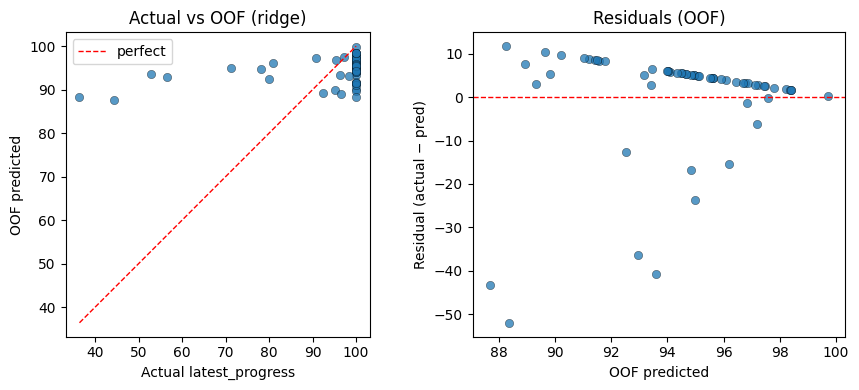


=== Who drives error? (largest |OOF residual|) ===


,resident_id,actual,pred_oof,pred_train_fit,oof_error,abs_oof_error
51,52,36.4,88.359256,76.252276,-51.959256,51.959256
8,9,44.4,87.683126,80.941563,-43.283126,43.283126
0,1,52.8,93.587879,86.763749,-40.787879,40.787879
43,44,56.5,92.951192,84.962847,-36.451192,36.451192
7,8,71.3,94.977809,91.833103,-23.677809,23.677809
53,54,78.1,94.848405,93.917928,-16.748405,16.748405
4,5,80.8,96.179491,91.930919,-15.379491,15.379491
9,10,80.0,92.522713,92.623082,-12.522713,12.522713


=== Highest actual progress (sanity check) ===


,resident_id,actual,pred_oof,pred_train_fit,oof_error,abs_oof_error
30,31,100.0,94.679744,96.403750,5.320256,5.320256
26,27,100.0,94.014875,95.425976,5.985125,5.985125
28,29,100.0,99.719783,100.749137,0.280217,0.280217
29,30,100.0,93.437460,94.639432,6.562540,6.562540
1,2,100.0,97.214405,97.964543,2.785595,2.785595
31,32,100.0,96.854114,97.473919,3.145886,3.145886
32,33,100.0,90.199010,92.868049,9.800990,9.800990
33,34,100.0,91.430446,93.674068,8.569554,8.569554



=== Which inputs mattered? (ridge, fit on all rows) ===


,abs_coef
num__has_special_needs,1.530077
num__edu_earliest_progress,0.953565
num__hw_mean_bmi,0.807246
num__hw_mean_energy_level_score,0.794432
num__hw_mean_nutrition_score,0.720618
...,...
num__is_pwd,0.000839
cat__pwd_type_Unknown,0.000183
num__days_to_first_edu_record,0.000000
num__n_intervention_plans,0.000000


In [4]:
# -----------------------------------------------------------------------------
# Phase 5 — Evaluation: OOF metrics, plots, residuals, feature signal
# -----------------------------------------------------------------------------
# Requires Phase 4: girls_pipeline (fitted), girls_cv_scores, girls_model_name, cv, X_girls, y_girls, girls_df, TARGET_GIRLS
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))

y_oof = cross_val_predict(girls_pipeline, X_girls, y_girls, cv=cv)

mae_oof = mean_absolute_error(y_girls, y_oof)
rmse_oof = root_mean_squared_error(y_girls, y_oof)
r2_oof = r2_score(y_girls, y_oof)

y_hat_train = girls_pipeline.predict(X_girls)
mae_train = mean_absolute_error(y_girls, y_hat_train)
r2_train = r2_score(y_girls, y_hat_train)

cv_mae_mean = float(-girls_cv_scores["test_neg_mae"].mean())
cv_mae_std = float(girls_cv_scores["test_neg_mae"].std())
y_mean = float(y_girls.mean())

print("=== How to read these numbers ===")
print(
    "• MAE  = average |error| in progress points when each row was 'new' (OOF).\n"
    "• RMSE = punishes big misses more than MAE.\n"
    "• R²   = variance explained on this sample (can be negative with small N).\n"
    "• OOF  = honest for this dataset; 'train' uses the model that saw every row.\n"
)

print("=== Out-of-fold (honest) performance ===")
print(f"MAE:  {mae_oof:.2f} progress points  (~{100 * mae_oof / y_mean:.1f}% of mean progress {y_mean:.1f})")
print(f"RMSE: {rmse_oof:.2f}")
print(f"R²:   {r2_oof:.3f}")

print("\n=== Same as Phase 4 aggregated CV scores ===")
print(f"CV MAE (mean ± std): {cv_mae_mean:.2f} ± {cv_mae_std:.2f}")

print("\n=== Overfitting check ===")
print(f"Train MAE (saw all rows): {mae_train:.2f}")
print(f"OOF MAE (did not see row): {mae_oof:.2f}")
gap_mae = mae_oof - mae_train
print(f"Gap (OOF − train MAE):     {gap_mae:.2f}  → positive means tighter fit on training than generalization.")
print(f"Train R²: {r2_train:.3f}  |  OOF R²: {r2_oof:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
ax0, ax1 = axes
ax0.scatter(y_girls, y_oof, alpha=0.75, edgecolors="k", linewidths=0.3)
lims = [min(y_girls.min(), y_oof.min()), max(y_girls.max(), y_oof.max())]
ax0.plot(lims, lims, "r--", lw=1, label="perfect")
ax0.set_xlabel(f"Actual {TARGET_GIRLS}")
ax0.set_ylabel("OOF predicted")
ax0.set_title(f"Actual vs OOF ({girls_model_name})")
ax0.legend()
ax0.set_aspect("equal", adjustable="box")

resid = y_girls.values - y_oof
ax1.axhline(0, color="r", linestyle="--", lw=1)
ax1.scatter(y_oof, resid, alpha=0.75, edgecolors="k", linewidths=0.3)
ax1.set_xlabel("OOF predicted")
ax1.set_ylabel("Residual (actual − pred)")
ax1.set_title("Residuals (OOF)")
plt.tight_layout()
plt.show()

print("\n=== Who drives error? (largest |OOF residual|) ===")
cmp = pd.DataFrame(
    {
        "resident_id": girls_df["resident_id"].values,
        "actual": y_girls.values,
        "pred_oof": y_oof,
        "pred_train_fit": y_hat_train,
    }
)
cmp["oof_error"] = cmp["actual"] - cmp["pred_oof"]
cmp["abs_oof_error"] = cmp["oof_error"].abs()
display(cmp.sort_values("abs_oof_error", ascending=False).head(8))
print("=== Highest actual progress (sanity check) ===")
display(cmp.sort_values("actual", ascending=False).head(8))

prep = girls_pipeline.named_steps["prep"]
reg = girls_pipeline.named_steps["reg"]
feat_names = prep.get_feature_names_out()

print(f"\n=== Which inputs mattered? ({girls_model_name}, fit on all rows) ===")
if hasattr(reg, "feature_importances_"):
    imp = pd.Series(reg.feature_importances_, index=feat_names).sort_values(ascending=False)
    display(imp.to_frame("importance"))
elif hasattr(reg, "coef_"):
    imp = pd.Series(np.abs(reg.coef_).ravel(), index=feat_names).sort_values(ascending=False)
    display(imp.to_frame("abs_coef"))
else:
    print("No feature_importances_ or coef_ for this estimator.")



## Phase 6: Deployment

**What we do here:** Print an **OOF deployment summary** (MAE, R², **accuracy %** and **recall %** from a median high/low split), then save **`girls_pipeline`** with **`joblib`** to **`pipelines/girls_progress_pipeline_v1.sav`**, reload, and verify predictions on **`X_girls`**. The FastAPI app loads this file **optionally** (same pattern as growth): **`GET /health`** includes **`girls_progress_pipeline_loaded`**; **`POST /girls-progress/predict`** scores new rows (see **`app/services/girls_progress.py`**). Set **`GIRLS_PROGRESS_PIPELINE_PATH`** to override the default path.

**Checkpoint — Phase 6:** Hand off the `.sav` plus API docs for integration.


In [5]:
# -----------------------------------------------------------------------------
# Phase 6 — Deployment: OOF summary stats + save pipeline + reload check
# -----------------------------------------------------------------------------
# Requires Phases 3–4: X_girls, y_girls, cv, girls_pipeline, girls_model_name, TARGET_GIRLS
# (Phase 5 optional — OOF metrics are recomputed here.)
import joblib
import numpy as np
from pathlib import Path

from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score, recall_score
from sklearn.model_selection import cross_val_predict

y_oof_deploy = cross_val_predict(girls_pipeline, X_girls, y_girls, cv=cv)
mae_deploy = mean_absolute_error(y_girls, y_oof_deploy)
r2_deploy = r2_score(y_girls, y_oof_deploy)

_thr = float(np.median(y_girls))
_y_hi = (y_girls.values >= _thr).astype(int)
_p_hi = (y_oof_deploy >= _thr).astype(int)
_acc = accuracy_score(_y_hi, _p_hi)
_rec_high = recall_score(_y_hi, _p_hi, pos_label=1, zero_division=0)
_rec_low = recall_score(_y_hi, _p_hi, pos_label=0, zero_division=0)

print("=== Deployment summary (out-of-fold, same CV as Phase 4) ===")
print(
    "Model choice: Phase 4 compared 4 regressors (GB, HGB, RF, Ridge) and picked",
    f"'{girls_model_name}' by lowest CV MAE — not by the % below.",
)
print(f"MAE:  {mae_deploy:.2f} progress points  |  R²: {r2_deploy:.3f}")
print(f"Deployed regressor: {girls_model_name}")
print()
print(
    "Optional median-split % (regression was not trained on this):",
    f'"high" {TARGET_GIRLS} if actual and OOF pred ≥ median ({_thr:.2f}).',
)
print(
    "This accuracy is often low for regression: predictions near the median flip labels.",
)
print(f"OOF accuracy:  {100 * _acc:.1f}%")
print(f"Recall (high): {100 * _rec_high:.1f}%  (truly high → predicted high)")
print(f"Recall (low):  {100 * _rec_low:.1f}%  (truly low → predicted low)")
print()

_repo = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "Dataset").is_dir()),
    None,
)
if _repo is None:
    raise FileNotFoundError("Could not find Dataset/ — open Jupyter from inside the ml-pipelines repo.")
ARTIFACT_PATH = _repo / "pipelines" / "girls_progress_pipeline_v2.sav"
ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(girls_pipeline, ARTIFACT_PATH)
loaded = joblib.load(ARTIFACT_PATH)
_same = np.allclose(loaded.predict(X_girls), girls_pipeline.predict(X_girls), rtol=1e-5, atol=1e-8)

print(f"Saved girls progress pipeline to:\n  {ARTIFACT_PATH}")
print(f"Reload sanity check (predictions match): {_same}\n")
print("FastAPI (repo root): uvicorn app.main:app --reload")
print("  POST /girls-progress/predict — http://127.0.0.1:8000/docs")

=== Deployment summary (out-of-fold, same CV as Phase 4) ===
Model choice: Phase 4 compared 4 regressors (GB, HGB, RF, Ridge) and picked 'ridge' by lowest CV MAE — not by the % below.
MAE:  8.30 progress points  |  R²: 0.106
Deployed regressor: ridge

Optional median-split % (regression was not trained on this): "high" latest_progress if actual and OOF pred ≥ median (100.00).
This accuracy is often low for regression: predictions near the median flip labels.
OOF accuracy:  26.7%
Recall (high): 0.0%  (truly high → predicted high)
Recall (low):  100.0%  (truly low → predicted low)

Saved girls progress pipeline to:
  /Users/gnelman/Documents/BYU/IS JUNIOR CORE/Winter 2026/Case Studies/INTEX II/Source Code/keeper/ml-pipelines/pipelines/girls_progress_pipeline_v2.sav
Reload sanity check (predictions match): True

FastAPI (repo root): uvicorn app.main:app --reload
  POST /girls-progress/predict — http://127.0.0.1:8000/docs


## Pipeline summary

This notebook builds a **resident-level regression model** for "girls progressing" using CSVs under `Dataset/lighthouse_csv_v7/` (residents, education, health, interventions, home visitations, safehouses). Donor/social files are out of scope and only tagged in Phase 2 for narration.

**Goal:** Predict each resident's **most recent education progress** as **`latest_progress`** — the `progress_percent` from her **most recent** `education_records` row — so staff can explore **who tends to sit higher or lower** on that scale for planning and reporting. **`latest_progress` is not in `X`** (no target leakage).

**Flow:**

1. **Data understanding (Phase 2)** — Inventory all CSVs, tag PRIMARY / SECONDARY / peripheral / other pipelines, and check **`resident_id`** overlap and basic `progress_percent` profiles.
2. **Data preparation (Phase 3)** — **One row per resident** (~**60**). Build **`latest_progress`** from the most recent education record per resident. **Features** combine: parsed ages / length of stay; vulnerability **subcategory** flags and family flags; **safehouse region**; **health** numeric means (bmi only, not redundant height/weight) and a composite checkup **engagement rate**; **counts** of education records, intervention plans, and home visitations; **visitation rate** normalised by stay length; **`edu_earliest_progress`** and **`edu_earliest_attendance_rate`** (first-record baseline — different row from target, zero leakage); **`days_to_first_edu_record`** (integration speed); plus **categorical** case/referral/risk/reintegration/education-level/region fields. `assigned_social_worker`, `province`, and safehouse `status` are excluded (overfitting / zero-variance risks at n=60). Strip/fill categoricals and numeric gaps, then **`build_girls_preprocessor()`**: median impute + **`StandardScaler`** on numerics, mode + **`OneHotEncoder`** on categoricals (Phase 4 refits inside CV on training folds only).
3. **Modeling (Phase 4)** — Compare **`GradientBoostingRegressor`**, **`HistGradientBoostingRegressor`**, **`RandomForestRegressor`**, and **`Ridge`** in a single sklearn **`Pipeline`**. **5-fold shuffled `KFold`** (row-level, not grouped by resident). Pick **lowest mean CV MAE** in **progress points** (0–100); tie-break **higher CV R²**. Refit the winner on **all rows** → **`girls_pipeline`**.
4. **Evaluation (Phase 5)** — **Out-of-fold** predictions, residual-style tables (largest OOF errors, highest actual progress), train vs CV gap, and **feature importances** or **|coef|** from the model fit on full data (exploratory, not causal).
5. **Deployment (Phase 6)** — Recompute OOF **MAE** / **R²**; optional **median-split** "high vs low" **accuracy / recall** (post hoc on regression outputs — interpret cautiously). Save **`girls_pipeline`** to **`pipelines/girls_progress_pipeline_v2.sav`**, reload check. FastAPI: **`GET /health`** → **`girls_progress_pipeline_loaded`**; **`POST /girls-progress/predict`** (see **`app/services/girls_progress.py`**); override path with **`GIRLS_PROGRESS_PIPELINE_PATH`** if needed.

**Contrast:** This pipeline is **one row per resident** with **historical aggregates**. The **`girls_education_trajectory`** notebook is **record-level** with **forward prediction** and **GroupKFold** by resident — different question and validation design.

**Caveats:** **Small *N*** and many columns after one-hot; use outputs to **support judgment**, not as definitive rankings. Associations are **not** proof of causation.